In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movies = pd.read_csv('../../datos/movie_recomendations/movies_cleaned.csv')
ratings = pd.read_csv('../../datos/movie_recomendations/ratings_cleaned.csv')

In [3]:
print(f"Cantidad Peliculas: {len(movies)}")
print(f"Cantidad Ratings: {len(ratings)}")

Cantidad Peliculas: 57238
Cantidad Ratings: 24973190


In [4]:
movies.head(5)

,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1995.0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1995.0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1995.0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,1995.0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1995.0


In [5]:
ratings.head(5)

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


# RATINGS

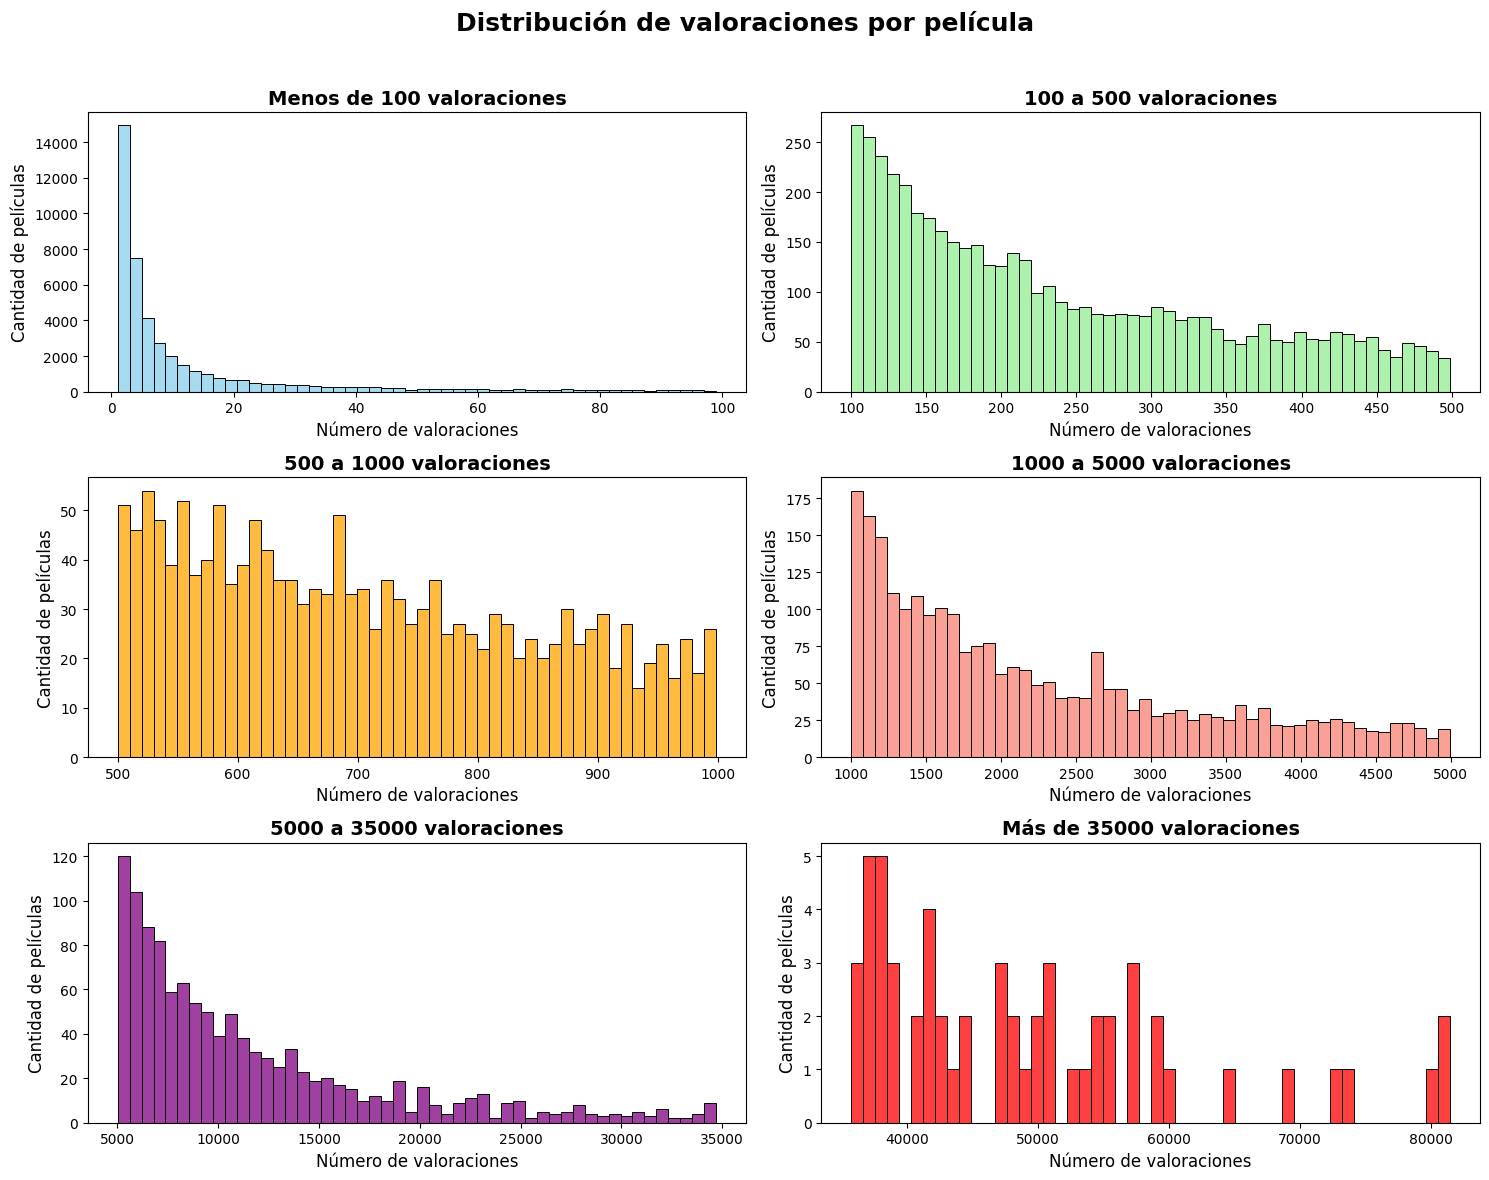

In [6]:
# Definir rangos, colores y títulos
bins_ranges = [
    (0, 100),
    (100, 500),
    (500, 1000),
    (1000, 5000),
    (5000, 35000),
    (35000, 100000)
]
colors = ['skyblue', 'lightgreen', 'orange', 'salmon', 'purple', 'red']
titles = [
    'Menos de 100 valoraciones',
    '100 a 500 valoraciones',
    '500 a 1000 valoraciones',
    '1000 a 5000 valoraciones',
    '5000 a 35000 valoraciones',
    'Más de 35000 valoraciones'
]

# Calcular número de valoraciones por película
movie_counts = ratings['movieId'].value_counts()

# Crear figura con subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

# Generar cada gráfico
for i, (low, high) in enumerate(bins_ranges):
    filtered_data = movie_counts[(movie_counts >= low) & (movie_counts < high)]
    sns.histplot(filtered_data, bins=50, kde=False, color=colors[i], edgecolor='black', ax=axes[i])
    
    axes[i].set_title(titles[i], fontsize=14, weight='bold')
    axes[i].set_xlabel('Número de valoraciones', fontsize=12)
    axes[i].set_ylabel('Cantidad de películas', fontsize=12)
    axes[i].tick_params(axis='both', labelsize=10)

# Eliminar subplot vacío si hay impares
if len(bins_ranges) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Distribución de valoraciones por película', fontsize=18, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajuste para el título principal
plt.show()

# GENEROS PELICULAS

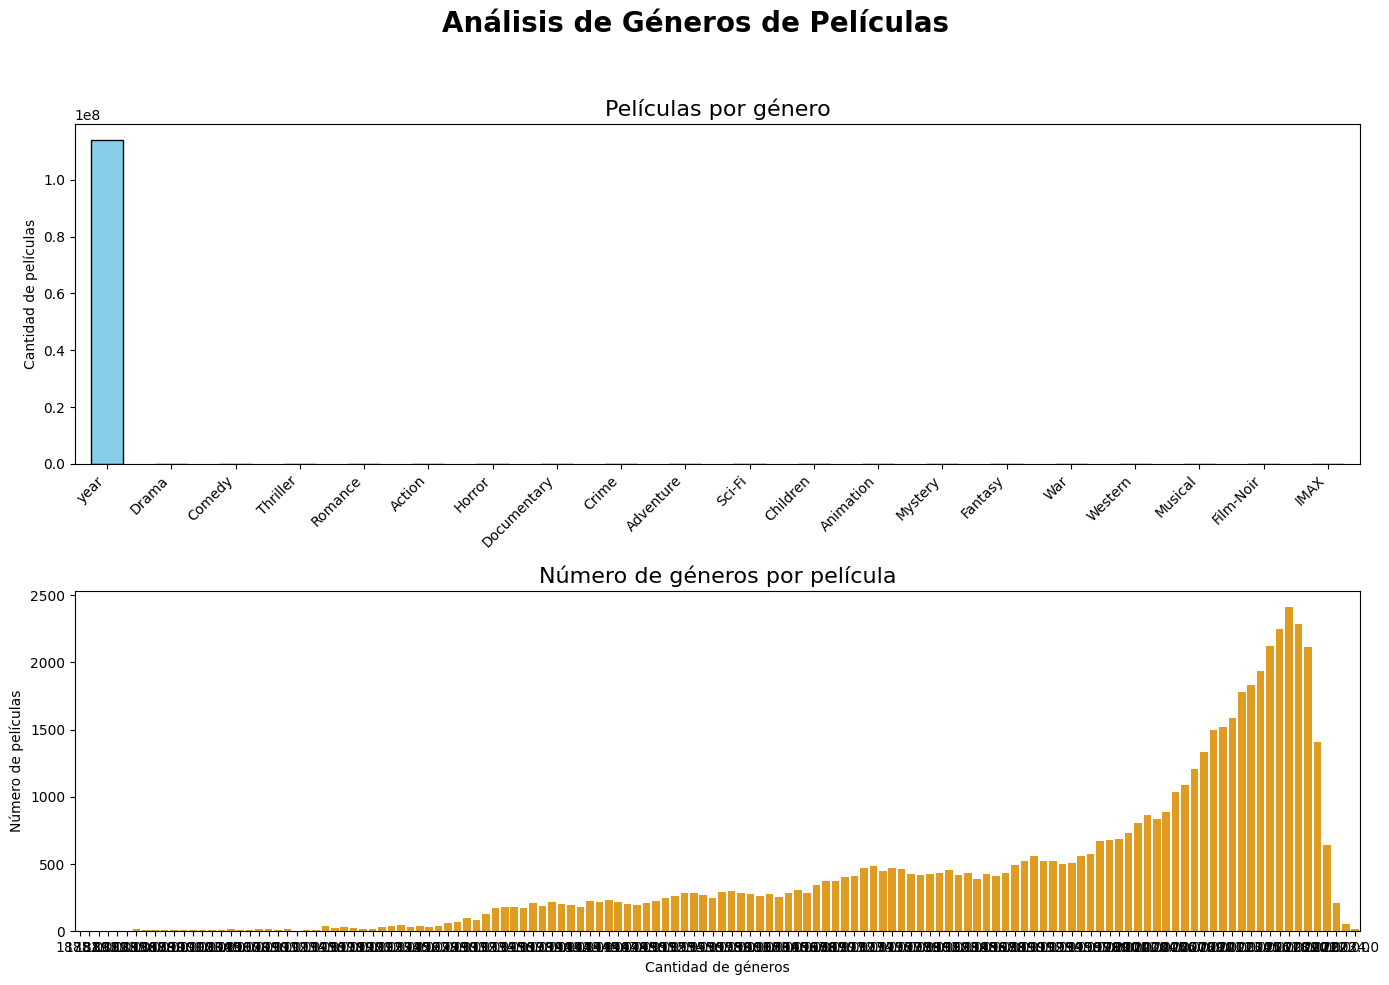

In [7]:
# Columnas de géneros (asumiendo que las dos primeras son movieId y title)
genre_cols = movies.columns[2:]

# Sumar cuántas películas hay por género
genre_counts = movies[genre_cols].sum().sort_values(ascending=False)

# Calcular cantidad de géneros por película
movies['genre_count'] = movies[genre_cols].sum(axis=1)

# Crear subplots (2 filas, 1 columna)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Análisis de Géneros de Películas', fontsize=20, weight='bold')
plt.subplots_adjust(hspace=0.4)

# === 1. Barras: cantidad por género ===
genre_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Películas por género', fontsize=16)
axes[0].set_ylabel('Cantidad de películas')
axes[0].set_xticklabels(genre_counts.index, rotation=45, ha='right')

# === 2. Histograma: número de géneros por película ===
sns.countplot(x='genre_count', data=movies, color='orange', ax=axes[1])
axes[1].set_title('Número de géneros por película', fontsize=16)
axes[1].set_xlabel('Cantidad de géneros')
axes[1].set_ylabel('Número de películas')

# Mostrar
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()